# Introducing LightSHAP

LightSHAP is a light-weight implementation of SHAP (SHapley Additive exPlanations). It does not depend on the original shap library.

In [1]:
import catboost
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf

# pip install lightshap
from lightshap import explain_any, explain_tree

c:\Users\mayer\lightshap_test\.venv\Lib\site-packages\lightshap\explainers\parallel.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Prepare data

In [2]:
df0 = sns.load_dataset("diamonds")

df = df0.assign(
    log_carat=lambda x: np.log(x.carat),
    log_price=lambda x: np.log(x.price),
)

# Features only
X = df[["log_carat", "clarity", "color", "cut"]]

## Boosted trees

LightSHAP provides a convenient API for native TreeSHAP of XGBoost, LightGBM, and CatBoost.

In [3]:
# Without validation strategy for simplicity
gbt = catboost.CatBoostRegressor(
    iterations=100, depth=4, cat_features=["clarity", "color", "cut"], verbose=0
)
_ = gbt.fit(X, y=df.log_price)


### SHAP analysis

<Axes: >

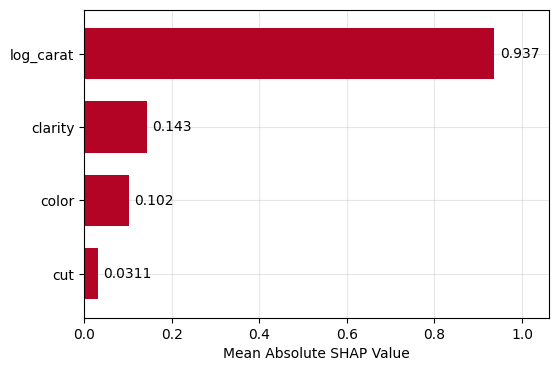

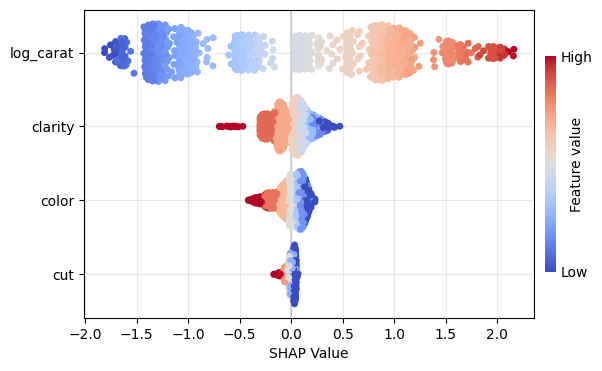

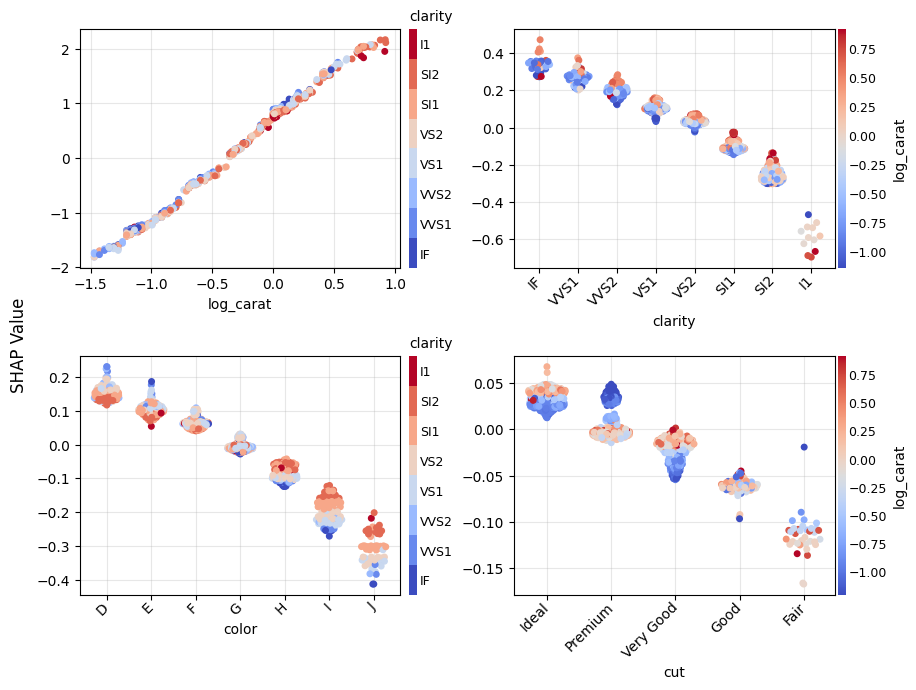

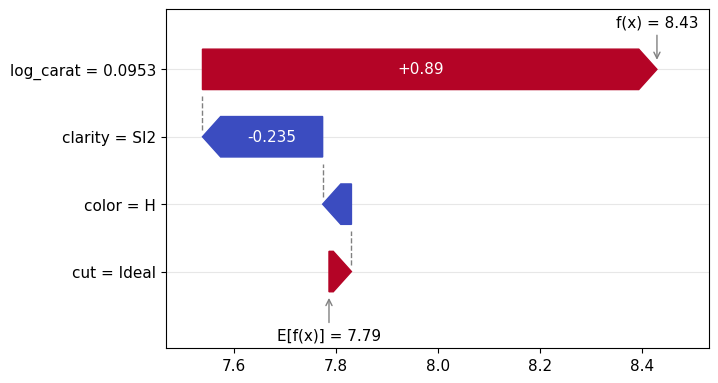

In [4]:
X_explain = X.sample(1000, random_state=0)
gbt_explanation = explain_tree(gbt, X_explain)

gbt_explanation.plot.bar()
gbt_explanation.plot.beeswarm()
gbt_explanation.plot.scatter(sharey=False)
gbt_explanation.plot.waterfall(row_id=0)

## Any model

LightSHAP contains exact and sampling versions of KernelSHAP and Permutation SHAP.

Let's fit a linear regression with natural cubic spline for log_carat and interaction between clarity and color.

In [5]:
lm = smf.ols("log_price ~ cr(log_carat, df=4) + clarity * color + cut", data=df)
lm = lm.fit()

### SHAP analysis

Permutation SHAP (exact)


  0%|          | 0/1000 [00:00<?, ?it/s]

<Axes: >

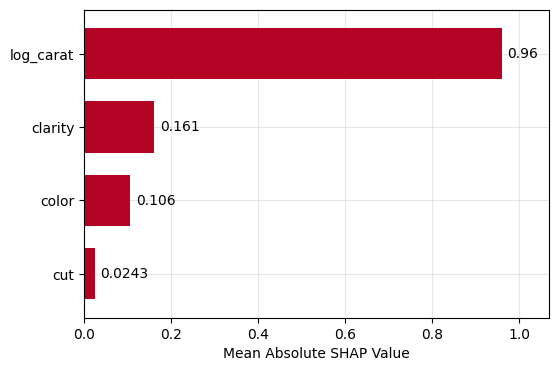

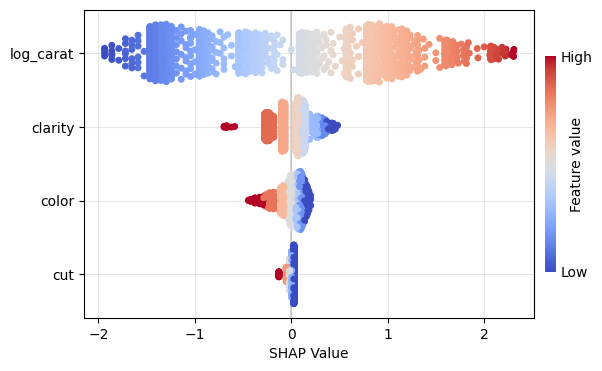

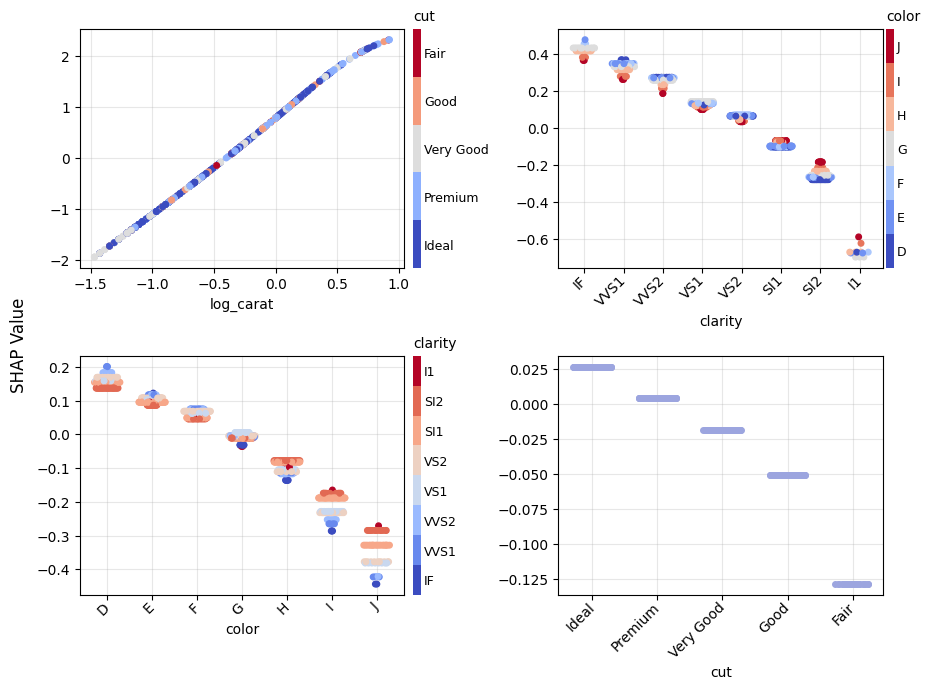

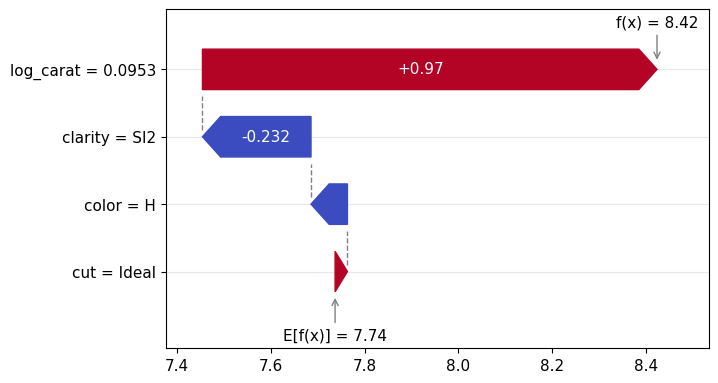

In [6]:
X_explain = X.sample(1000, random_state=0)
lm_explanation = explain_any(lm.predict, X_explain)  # 5s on laptop

lm_explanation.plot.bar()
lm_explanation.plot.beeswarm()
lm_explanation.plot.scatter(sharey=False)
lm_explanation.plot.waterfall(row_id=0)